In [ ]:
from google.colab import files
files.upload()

aswin.s 24BAD014
Top Similar Users:
 userId
5343    0.412117
5190    0.411899
1481    0.392110
1283    0.386597
5705    0.360898
Name: 1, dtype: float64

Top Recommendations:
 title
Little Mermaid, The (1989)          4.212684
Jungle Book, The (1967)             3.438253
Silence of the Lambs, The (1991)    3.373625
Lady and the Tramp (1955)           2.599194
Sleeping Beauty (1959)              2.389318
dtype: float64

RMSE: 2.8492557398035645
MAE: 2.443624149451182

Sparsity: 0.9553163743776871


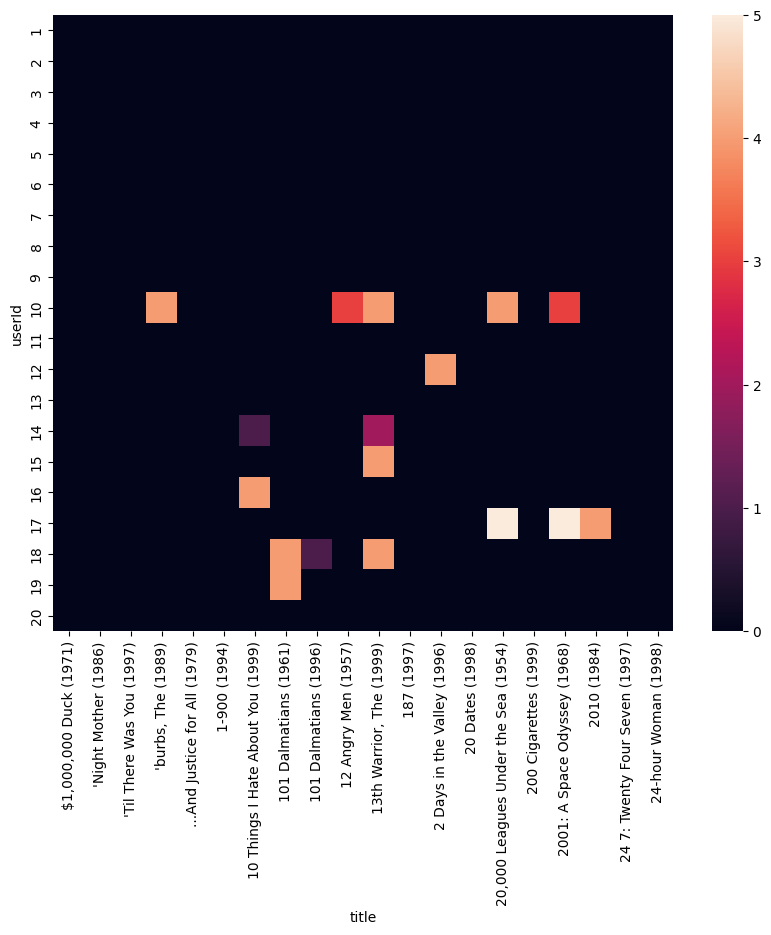

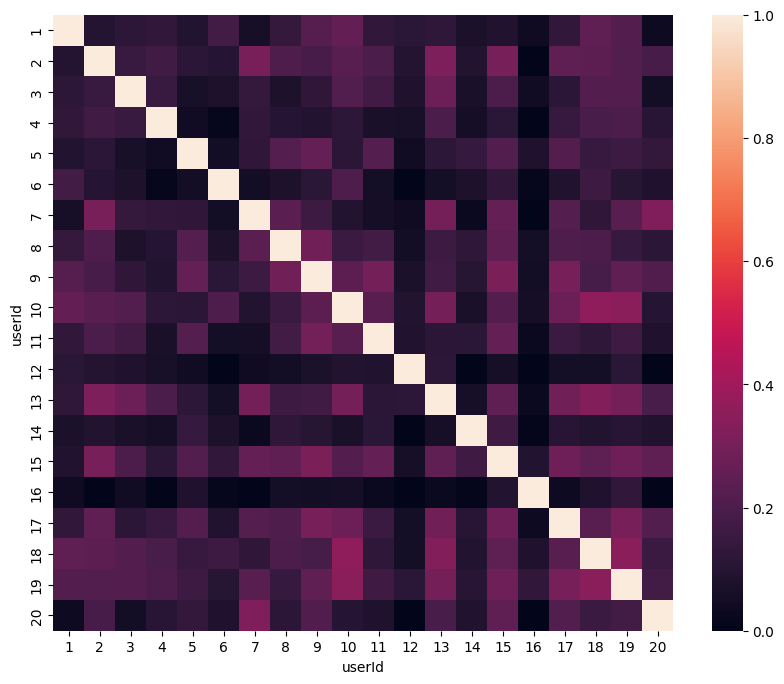

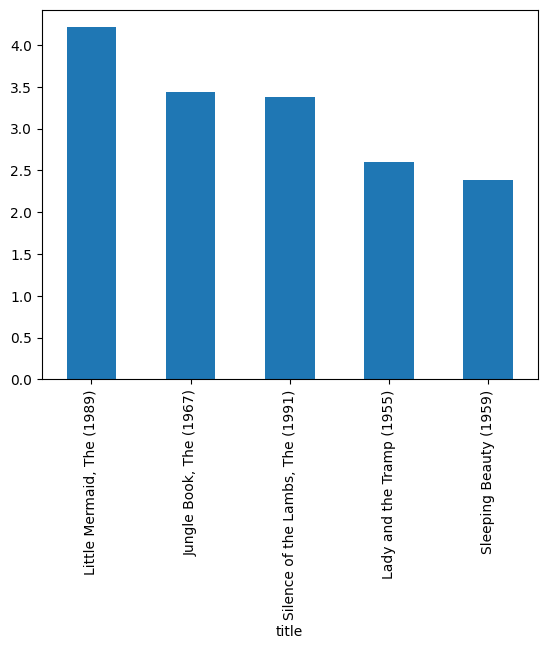

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("aswin.s 24BAD014")

ratings = pd.read_csv('ratings.dat', sep='::', engine='python',
                      names=['userId', 'movieId', 'rating', 'timestamp'],
                      encoding='latin-1')

movies = pd.read_csv('movies.dat', sep='::', engine='python',
                     names=['movieId', 'title', 'genres'],
                     encoding='latin-1')

users = pd.read_csv('users.dat', sep='::', engine='python',
                    names=['userId', 'gender', 'age', 'occupation', 'zip'],
                    encoding='latin-1')

data = pd.merge(pd.merge(ratings, movies, on='movieId'), users, on='userId')

user_item_matrix = data.pivot_table(index='userId', columns='title', values='rating')
user_item_matrix = user_item_matrix.fillna(0)

user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

user_id = 1
similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6]

def predict_ratings(user_id):
    sim_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6]
    sim_scores = sim_users.values
    sim_ids = sim_users.index
    weighted_ratings = np.dot(sim_scores, user_item_matrix.loc[sim_ids])
    sum_sim = np.sum(sim_scores)
    return weighted_ratings / sum_sim

predicted_ratings = predict_ratings(user_id)
predicted_ratings = pd.Series(predicted_ratings, index=user_item_matrix.columns)

unseen_movies = user_item_matrix.loc[user_id] == 0
recommended_movies = predicted_ratings[unseen_movies].sort_values(ascending=False).head(5)

actual = user_item_matrix.loc[user_id]
predicted = predicted_ratings

mask = actual > 0
rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))
mae = mean_absolute_error(actual[mask], predicted[mask])

print("Top Similar Users:\n", similar_users)
print("\nTop Recommendations:\n", recommended_movies)
print("\nRMSE:", rmse)
print("MAE:", mae)

sparsity = 1.0 - np.count_nonzero(user_item_matrix) / user_item_matrix.size
print("\nSparsity:", sparsity)

plt.figure(figsize=(10,8))
sns.heatmap(user_item_matrix.iloc[:20, :20])
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(user_similarity_df.iloc[:20, :20])
plt.show()

recommended_movies.plot(kind='bar')
plt.show()

aswin.s 24BAD014
Top Similar Items:
 title
Computer Wore Tennis Shoes, The (1970)    0.308903
Blackbeard's Ghost (1968)                 0.301220
Barefoot Executive, The (1971)            0.300920
That Darn Cat! (1965)                     0.275245
Candleshoe (1977)                         0.271330
Name: $1,000,000 Duck (1971), dtype: float64

Recommended Items:
 title
Star Wars: Episode V - The Empire Strikes Back (1980)    0.000825
Lion King, The (1994)                                    0.000800
Raiders of the Lost Ark (1981)                           0.000794
Groundhog Day (1993)                                     0.000789
Shawshank Redemption, The (1994)                         0.000776
dtype: float64

RMSE: 871.5975509864214
Precision@5: 0.0


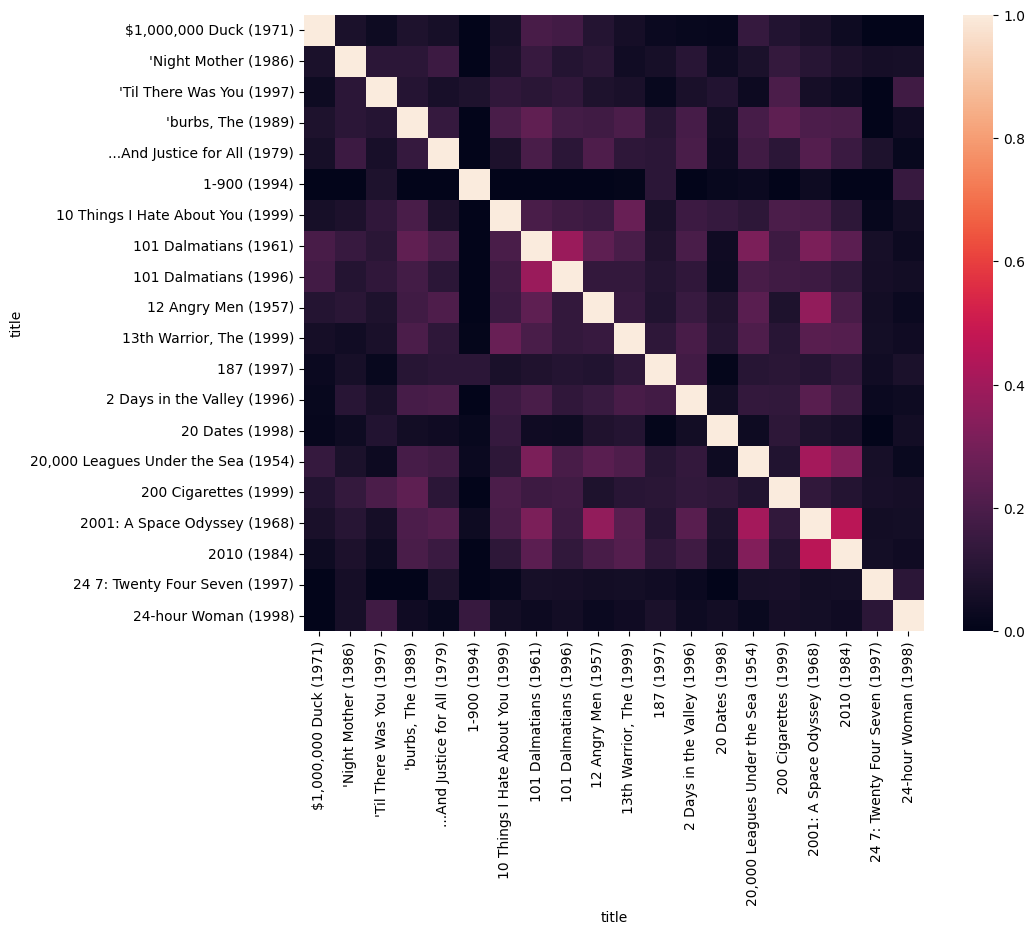

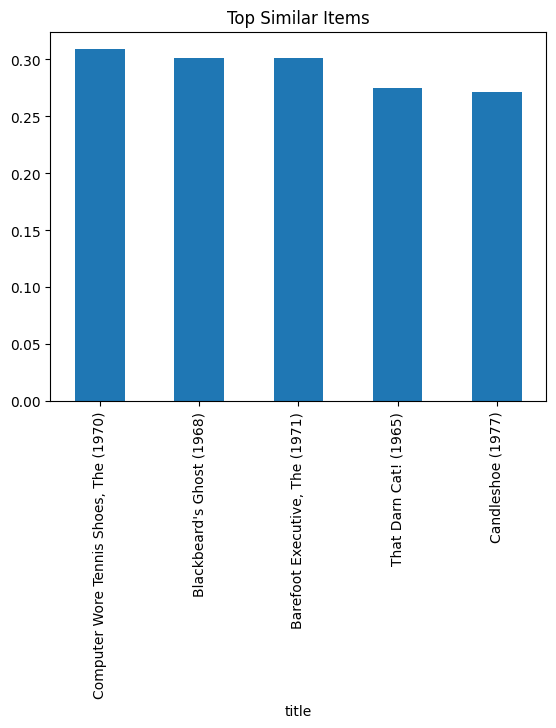

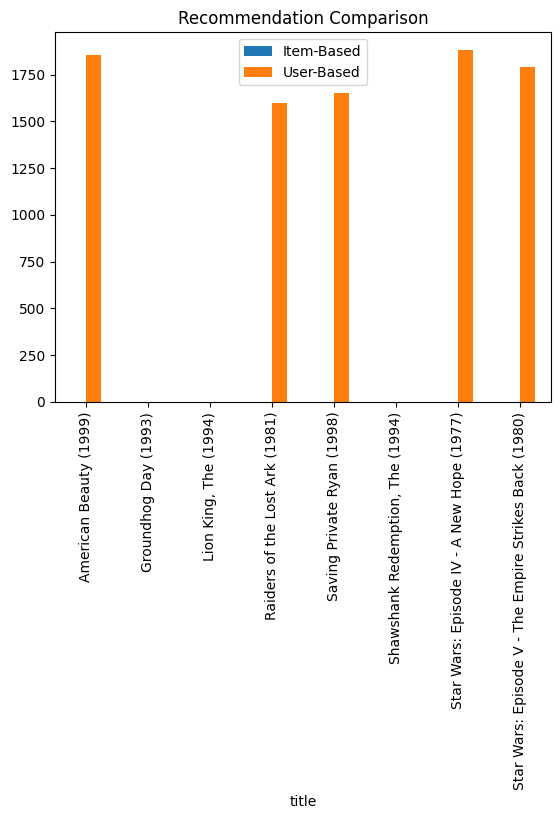

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

print("aswin.s 24BAD014")

ratings = pd.read_csv('ratings.dat', sep='::', engine='python',
                      names=['userId', 'movieId', 'rating', 'timestamp'],
                      encoding='latin-1')

movies = pd.read_csv('movies.dat', sep='::', engine='python',
                     names=['movieId', 'title', 'genres'],
                     encoding='latin-1')

data = pd.merge(ratings, movies, on='movieId')

item_user_matrix = data.pivot_table(index='title', columns='userId', values='rating')
item_user_matrix = item_user_matrix.fillna(0)

item_similarity = cosine_similarity(item_user_matrix)
item_similarity_df = pd.DataFrame(item_similarity,
                                  index=item_user_matrix.index,
                                  columns=item_user_matrix.index)

item_name = item_user_matrix.index[0]
similar_items = item_similarity_df[item_name].sort_values(ascending=False)[1:6]

def recommend_items(user_id):
    user_ratings = item_user_matrix.iloc[:, user_id-1]
    rated_items = user_ratings[user_ratings > 0].index

    scores = pd.Series(dtype=float)

    for item in rated_items:
        sim_scores = item_similarity_df[item]
        scores = scores.add(sim_scores * user_ratings[item], fill_value=0)

    scores = scores / scores.sum()
    scores = scores.drop(rated_items)
    return scores.sort_values(ascending=False).head(5)

recommended = recommend_items(1)

user_item_matrix = data.pivot_table(index='userId', columns='title', values='rating').fillna(0)
user_similarity = cosine_similarity(user_item_matrix)

def user_based(user_id):
    sim_scores = user_similarity[user_id-1]
    weighted = np.dot(sim_scores, user_item_matrix)
    return weighted

pred_item = recommend_items(1)

actual = user_item_matrix.loc[1]
predicted = pd.Series(user_based(1), index=user_item_matrix.columns)

mask = actual > 0
rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))

def precision_at_k(recommended, actual, k=5):
    relevant = actual[actual > 3].index
    rec_k = recommended.index[:k]
    return len(set(rec_k) & set(relevant)) / k

precision = precision_at_k(pred_item, actual)

popularity = data['title'].value_counts()

print("Top Similar Items:\n", similar_items)
print("\nRecommended Items:\n", recommended)
print("\nRMSE:", rmse)
print("Precision@5:", precision)

plt.figure(figsize=(10,8))
sns.heatmap(item_similarity_df.iloc[:20, :20])
plt.show()

similar_items.plot(kind='bar')
plt.title("Top Similar Items")
plt.show()

user_rec = pd.Series(user_based(1), index=user_item_matrix.columns).sort_values(ascending=False).head(5)

comparison = pd.DataFrame({
    'Item-Based': recommended,
    'User-Based': user_rec
})

comparison.plot(kind='bar')
plt.title("Recommendation Comparison")
plt.show()